In [19]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [20]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [21]:
##########################################################################################
#Plotting
plotting=False #KEEP FALSE WHEN JOB ARRAY IS RUNNING
plotting=True

In [22]:
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

In [ ]:
if plotting==True:
        
    #Produced averaged profiles for plotting
    def averaged_profiles(profile):
        out_var = profile[(profile[:, 1] > 1)]  # gets rid of rows that have no data
        out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
        return out_var
    
    ####################################################################
    res='1km'
    # res='250m'
    label=1
    
    #Uses Plotting Function 
    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    # if type=='general':
    #     fig.suptitle(f"average eulerian updraft property profiles") 
    # if type=='cloudy':
    #     fig.suptitle(f"average eulerian cloudy updraft property profiles")
    fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Profiles (Eulerian)")
    #CHANGE TITLE IF CTRL CASE IF USING
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()
    # plt.tight_layout()
    
    ####################################################################
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
    
        dir2=dir+'Project_Algorithms/Domain_Profiles/'
        if type == "general":
            input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 

        vars=['w','qv','qc_plus_qi','th','th_e','buoyancy', 'HMC']
        with h5py.File(input_file, 'r') as f:
            for var in vars:
                globals()[f"profile_{var}"]=np.array(f[f"profile_{var}"])
                # globals()[f"profile_{var}_SE"]=ProfileStandardError(globals()[f"profile_{var}"],np.array(f[f"profile_{var}_squares"])); factor=1.96
                globals()[f"profile_{var}_SE"]=ProfileStandardDeviation(globals()[f"profile_{var}"],np.array(f[f"profile_{var}_squares"])); factor=1

        
        #Plotting function
        def plotting_func(out_var,axis,label,color):
            axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
            axis.grid(True)
        
        #Uses Averaged_Profiles Function
        for var in vars:
            globals()[f"out_{var}"] = averaged_profiles(globals()[f"profile_{var}"])
        
        vars=['w','qv','qc_plus_qi','th','th_e','buoyancy','HMC'] 
        # vars=['w'] #TESTING
        axises=[ax1,ax2,ax3,ax4,ax5,ax6,ax7] #ax5
        xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)', 'HMC (g/kg/s)'] 
        for var,axis,xlabel in zip(vars,axises,xlabels):
            if type=='general':
                color='k'
            elif type=='cloudy':
                color='blue'

            #converts qv and qc from kg/kg=>g/kg
            if var in ['qv','qc_plus_qi','HMC']:
                globals()[f"out_{var}"][:,0]*=1000
                globals()[f"profile_{var}_SE"][:,0]*=1000
                switch=1
            else:
                switch=1

            profile=globals()[f"out_{var}"]
            profile_SE=globals()[f"profile_{var}_SE"]
            plotting_func(profile,axis,label=type+' ',color=color)
            axis.fill_betweenx(profile[:, 1], profile[:, 0] - factor*profile_SE[:,0]*switch, profile[:, 0] + factor*profile_SE[:,0], color=color, alpha=0.1)
            axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
    
            if axis==ax2:
                axis.legend(); #add legend
    
            if axis==ax7:
                apply_scientific_notation([axis])
    
    
    #MEAN CLOUD BASE
    qcqi_profile=averaged_profiles(profile_qc_plus_qi)
    where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
    cloudbase=qcqi_profile[where_cloudbase,1]
    for axis in axises:
        axis.axhline(cloudbase,color='purple',linestyle='dashed')
    
    
    
    plt.tight_layout()
    #save plot
    # plt.savefig(dir+f'Project_Algorithms/plots/eulerian_updraft_profiles_{res}_{t_res}_{Np_str}.jpg', bbox_inches='tight', dpi=300)

In [153]:
#TESTING THETA PLOTS
##############################

In [25]:
# #MEAN CLOUD BASE
# qcqi_profile=averaged_profiles(profile_qc_plus_qi)
# where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
# cloudbase=qcqi_profile[where_cloudbase,1]
# for axis in axises:
#     axis.axhline(cloudbase,color='purple',linestyle='dashed')

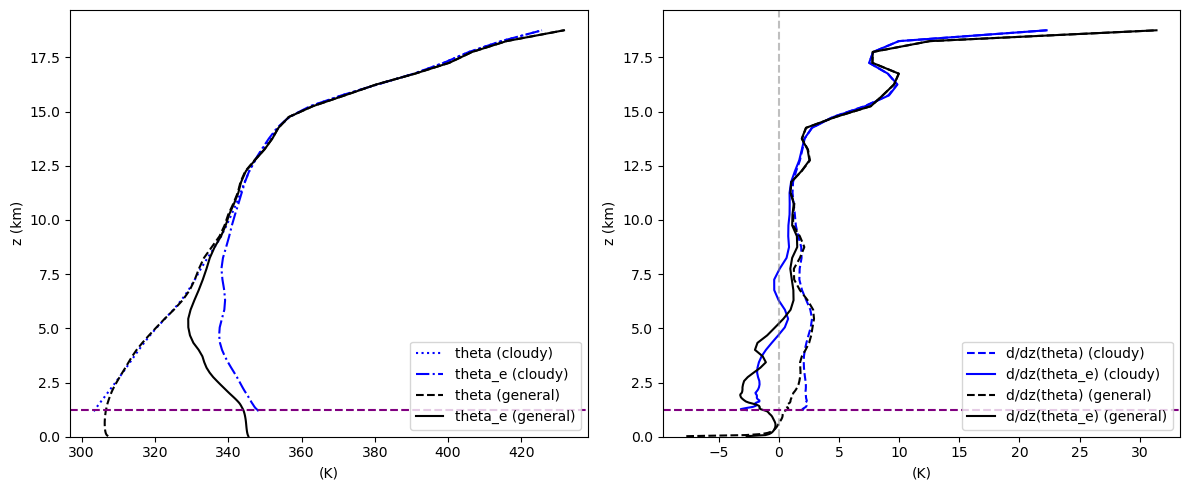

In [26]:
def load_and_prepare(type_):
    dir2 = dir + 'Project_Algorithms/Domain_Profiles/'
    if type_ == "general":
        fname = f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'
    else:
        fname = f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'

    with h5py.File(dir2 + fname, 'r') as f:
        th = np.array(f["profile_th"])
        th_e = np.array(f["profile_th_e"])

    # def prep(p):
    #     return np.column_stack([p[:,0]/p[:,1], p[:,2]])
    def prep(p):
        ratio = np.empty_like(p[:,0])
        np.divide(p[:,0], p[:,1], out=ratio, where=p[:,1]!=0)
        ratio[p[:,1]==0] = np.nan  # explicitly set where denom=0
        return np.column_stack([ratio, p[:,2]])

    return prep(th), prep(th_e)

def plot_profiles_and_derivs(p_th_c, p_th_e_c, p_th_g, p_th_e_g, out_c, out_e_c, out_g, out_e_g, cloudbase):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

    ax = axes[0]  # Left plot: Profiles
    ax.plot(p_th_c[:,0], p_th_c[:,1], 'b:', label='theta (cloudy)')
    ax.plot(p_th_e_c[:,0], p_th_e_c[:,1], 'b-.', label='theta_e (cloudy)')
    ax.plot(p_th_g[:,0], p_th_g[:,1], 'k--', label='theta (general)')
    ax.plot(p_th_e_g[:,0], p_th_e_g[:,1], 'k-', label='theta_e (general)')
    ax.axhline(cloudbase, color='purple', linestyle='dashed')

    ax.set_ylim(bottom=0)
    ax.legend(loc='lower right')
    ax.set_xlabel('(K)')
    ax.set_ylabel('z (km)')

    ax = axes[1]  # Right plot: Derivatives
    ax.plot(out_c[:,0], out_c[:,1], 'b--', label='d/dz(theta) (cloudy)')
    ax.plot(out_e_c[:,0], out_e_c[:,1], 'b-', label='d/dz(theta_e) (cloudy)')
    ax.plot(out_g[:,0], out_g[:,1], 'k--', label='d/dz(theta) (general)')
    ax.plot(out_e_g[:,0], out_e_g[:,1], 'k-', label='d/dz(theta_e) (general)')
    ax.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    ax.axhline(cloudbase, color='purple', linestyle='dashed')

    ax.set_ylim(bottom=0)
    ax.legend(loc='lower right')
    ax.set_xlabel('(K)')
    ax.set_ylabel('z (km)')

    plt.tight_layout()
    plt.show()


p_th_g, p_th_e_g = load_and_prepare('general')
p_th_c, p_th_e_c = load_and_prepare('cloudy')

out_g = Profile_Ddz(p_th_g)
out_e_g = Profile_Ddz(p_th_e_g)
out_c = Profile_Ddz(p_th_c)
out_e_c = Profile_Ddz(p_th_e_c)

plot_profiles_and_derivs(p_th_c, p_th_e_c, p_th_g, p_th_e_g, out_c, out_e_c, out_g, out_e_g, cloudbase)


In [27]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

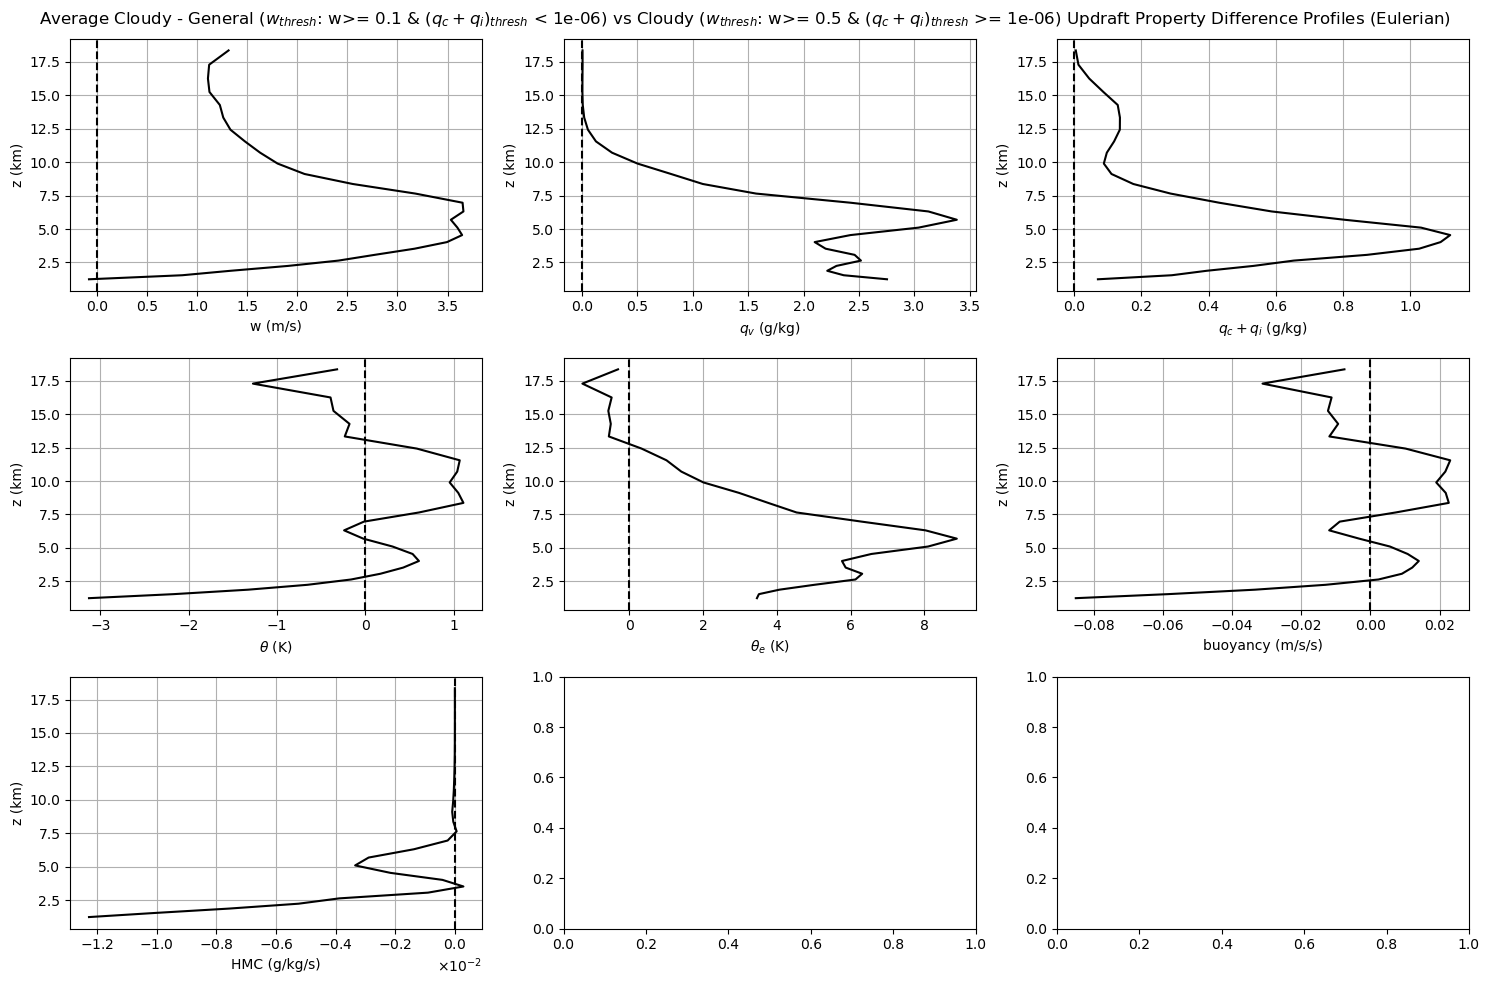

In [28]:
if plotting==True:
    #Plotting Differences
    def averaged_profiles(profile):
        out_var = profile[(profile[:, 1] > 1)]  # gets rid of rows that have no data
        out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
        return out_var
    
    label=1
    
        
    def get_data(type):
        dir2=dir+'Project_Algorithms/Domain_Profiles/'
        if type == "general":
            input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'
            
        with h5py.File(input_file, 'r') as f:
            globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
            globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
            globals()[f'{type}_profile_qc_plus_qi'] = np.array(f['profile_qc_plus_qi'])
            globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
            globals()[f'{type}_profile_th_e'] = np.array(f['profile_th_e'])
            globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])
            globals()[f'{type}_profile_HMC'] = np.array(f['profile_HMC'])
    
        
    def diff_plotting():
        #setting up figure
        fig, axs = plt.subplots(3, 3, figsize=(15, 10))
        fig.suptitle(f"Average Cloudy - General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Difference Profiles (Eulerian)")
        ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()
    
        #the plotting
        vars=['w','qv','qc_plus_qi','th','th_e','buoyancy','HMC']
        xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)','HMC (g/kg/s)'] #qi (g/kg)
        for xlabel,var in zip(xlabels,vars):
            
            if var=='w':axis=ax1
            elif var=='qv':axis=ax2
            elif var=='qc_plus_qi':axis=ax3
            elif var=='th':axis=ax4
            elif var=='th_e':axis=ax5
            elif var=='buoyancy':axis=ax6
            elif var=='HMC':axis=ax7
    
            #get profile
            types=['cloudy','general']
            get_data(types[0])
            out_var_one=globals()[f"{types[0]}_profile_{var}"]
            get_data(types[1])
            out_var_two=globals()[f"{types[1]}_profile_{var}"]
    
            #finding where cloudy updraft count goes below 10
            cutofflow=np.where(out_var_one[:,1]>10)[0][0]
            cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
           
            #averaging
            out_var_diff=average_difference(out_var_one,out_var_two)
    
            #converts qv and qc_plus_qi from kg/kg=>g/kg
            if var in ['qv','qc_plus_qi','qi','HMC']:
                out_var_diff[:,0]*=1000
            
            axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
            axis.axvline(0,color='k',linestyle='dashed')
            # axis.set_ylim(bottom=0,top=20)
            ## axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
            #labeling
            axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
            axis.grid(True)
            # axis.legend(fontsize='small') #only adds legend at final variable
    
            if axis==ax7:
                apply_scientific_notation([axis])
    
            # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
        plt.tight_layout()
    
    # #MEAN CLOUD BASE
    # for axis in axises:
    #     axis.axhline(cloudbase,color='purple',linestyle='dashed')
        
    diff_plotting() 
    # plt.savefig(dir+f'Project_Algorithms/plots/eulerian_updraft_profiles_diff_{res}_{t_res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) #save 

In [8]:
########################################
#TESTING

In [192]:
# type="general"
# # type="cloudy"
# dir2=dir+'Project_Algorithms/Domain_Profiles/'
# if type == "general":
#     input_file = dir2+f'job_out/general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
# elif type == "cloudy":
#     input_file = dir2+f'job_out/cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 

# with h5py.File(input_file, 'r') as f:
#     profile_w = np.array(f['profile_w'])
#     profile_w_squares = np.array(f['profile_w_squares'])


# import matplotlib.gridspec as gridspec
# profile_w_SE = ProfileStandardError(profile_w, profile_w_squares)
# # profile_w_SE = ProfileStandardDeviation(profile_w, profile_w_squares)

# out1 = profile_w_SE.copy()

# out2 = ProfileMean(profile_w)
# multiple = 1

# fig = plt.figure(figsize=(12, 5))
# gs = gridspec.GridSpec(1, 2, figure=fig)

# ax1 = fig.add_subplot(gs[0, 0])
# ax1.plot(out1[:, 0], out1[:, 1])

# ax2 = fig.add_subplot(gs[0, 1])
# profile=out2.copy();profile_SE=profile_w_SE.copy();switch=1
# ax2.plot(profile[:, 0], profile[:, 1], color='blue')
# ax2.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*profile_SE[:,0]*switch, profile[:, 0] + 1.96*profile_SE[:,0], color='blue', alpha=0.1)

# plt.tight_layout()
# plt.show()